# KNN 血糖预测模型

本 Notebook 使用 K-Nearest Neighbors (KNN) 算法进行血糖预测。
主要步骤包括：
1. 数据加载与预处理
2. 滑动窗口特征构建 (融合 Age 和 BMI)
3. 数据标准化
4. 模型训练
5. 评估指标计算 (MAE, RMSE, MAPE, RMSPE)
6. 结果可视化

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set scientific plotting style (referencing filter_comparison.ipynb)
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

In [95]:
# 加载训练集和测试集
train_path = '../../DataSplit/TrainTest/Train.csv'
test_path = '../../DataSplit/TrainTest/Test.csv'

df_train = pd.read_csv(train_path, parse_dates=['time'])
df_test = pd.read_csv(test_path, parse_dates=['time'])

print("训练集形状:", df_train.shape)
print("测试集形状:", df_test.shape)
df_train.head()

训练集形状: (83253, 5)
测试集形状: (11376, 5)


,id,time,gl,age,bmi
0,3,2012-01-01 00:00:00,89.539216,61.0,33.8
1,3,2012-01-01 00:05:00,90.070728,61.0,33.8
2,3,2012-01-01 00:10:00,90.366300,61.0,33.8
3,3,2012-01-01 00:15:00,90.450442,61.0,33.8
4,3,2012-01-01 00:20:00,90.347662,61.0,33.8


In [96]:
def create_dataset(data, n_past):
    """
    创建滑动窗口数据集 (单步预测)
    
    参数:
    data:包含 'id', 'gl', 'age', 'bmi' 列的 DataFrame
    n_past: 过去的时间步数 (滑动窗口大小)
    
    返回:
    X: 特征矩阵 (n_samples, n_features)
    y: 目标向量 (n_samples,) -> 下一个时间点的血糖值
    """
    X, y = [], []
    
    # 按受试者分组处理，避免跨受试者构建窗口
    for subject_id, group in data.groupby('id'):
        # 获取血糖值、年龄和BMI
        gl_values = group['gl'].values
        # 假设每个受试者的 age 和 bmi 是常数，取第一行即可
        age = group['age'].iloc[0] 
        bmi = group['bmi'].iloc[0] 
        
        # 确保数据足够长
        if len(gl_values) <= n_past:
            continue

        # 构建滑动窗口
        for i in range(n_past, len(gl_values)):
            # 过去 n_past 个时间步的血糖值
            past_gl = gl_values[i-n_past:i]
            
            # 将血糖序列与静态特征拼接
            # 特征向量: [gl_t-N, ..., gl_t-1, age, bmi]
            features = np.append(past_gl, [age, bmi])
            
            X.append(features)
            y.append(gl_values[i]) # 预测当前时间步 (即窗口后的第一个点)
            
    return np.array(X), np.array(y)

# 设定滑动窗口大小 (例如过去 12 个点，即 1 小时数据)
N_PAST = 12 

# 构建训练集和测试集 (均为单步预测数据)
print(f"正在构建滑动窗口数据集 (N_PAST={N_PAST})...")
X_train, y_train = create_dataset(df_train, N_PAST)
X_test, y_test = create_dataset(df_test, N_PAST)

print(f"构建特征后的训练集形状: X={X_train.shape}, y={y_train.shape}")
print(f"构建特征后的测试集形状: X={X_test.shape}, y={y_test.shape}")

正在构建滑动窗口数据集 (N_PAST=12)...
构建特征后的训练集形状: X=(81357, 14), y=(81357,)
构建特征后的测试集形状: X=(9480, 14), y=(9480,)


In [97]:
# 数据标准化
# KNN 对距离敏感，必须对特征进行标准化
scaler = StandardScaler()

# 在训练集上拟合 scaler，并转换训练集
X_train_scaled = scaler.fit_transform(X_train)

# 使用训练集的 scaler 转换测试集 (避免数据泄露)
X_test_scaled = scaler.transform(X_test)

print("前5个样本的标准化特征 (部分展示):")
print(X_train_scaled[:5, :5]) # 展示前5行前5列

前5个样本的标准化特征 (部分展示):
[[-0.56481287 -0.54096664 -0.52785235 -0.52437623 -0.5294274 ]
 [-0.54063864 -0.52751744 -0.52402228 -0.5290563  -0.54150676]
 [-0.52719544 -0.52368882 -0.52870075 -0.54113174 -0.55986749]
 [-0.52336852 -0.52836552 -0.54077206 -0.55948652 -0.58339317]
 [-0.52804314 -0.5404323  -0.55912055 -0.58300457 -0.61162988]]


In [98]:
# 构建 KNN 模型
# n_neighbors 是关键超参数，这里先设为 5，实际应用中可以通过交叉验证优化
knn_model = KNeighborsRegressor(n_neighbors=5)

# 训练模型
print("开始训练 KNN 模型...")
knn_model.fit(X_train_scaled, y_train)
print("模型训练完成。")

开始训练 KNN 模型...
模型训练完成。


In [99]:
# 设定预测步长: 30分钟 = 6个5分钟的时间步
PREDICTION_HORIZON = 1

def recursive_predict_single(model, scaler, initial_window_glucose, age, bmi, steps_ahead):
    """
    【递归预测】对单个样本进行多步预测
    
    核心思想：
    - 只用单步模型（训练时 horizon=1）
    - 预测 t+1，然后把 t+1 的预测值当作"真实值"
    - 更新窗口：[t-N+1, ..., t-1, t] -> [t-N+2, ..., t, t+1_pred]
    - 继续预测 t+2，再更新窗口
    - 循环直到预测出 t+steps_ahead
    
    ⚠️ 关键区别：不是直接预测 t+steps_ahead，而是一步步递推
    """
    # 当前glucose历史窗口（只包含glucose，不包含age/bmi）
    current_window = initial_window_glucose.copy()
    all_predictions = []
    
    # 🔁 递归循环：逐步预测
    for step in range(1, steps_ahead + 1):
        # Step 1: 构造当前时刻的完整特征
        # 特征 = [当前glucose窗口, age, bmi]
        feature = np.concatenate([current_window, [age, bmi]])
        feature = feature.reshape(1, -1)  # (1, n_features)
        
        # Step 2: 标准化
        feature_scaled = scaler.transform(feature)
        
        # Step 3: 用单步模型预测下一个时刻 (t+step)
        next_glucose_pred = model.predict(feature_scaled)[0]
        
        # Step 4: 保存预测值
        all_predictions.append(next_glucose_pred)
        
        # Step 5: 🔄 更新窗口（递归的核心！）
        # 移除最旧的值，添加刚预测的值
        # [gl_t-N, ..., gl_t-1] -> [gl_t-N+1, ..., gl_t-1, gl_t_pred]
        current_window = np.append(current_window[1:], next_glucose_pred)
        
        # 现在 current_window 包含了预测值，用于预测下一步
    
    return all_predictions  # [pred_t+1, pred_t+2, ..., pred_t+steps_ahead]


# 获取多步预测的真实标签
def get_multistep_targets(data, n_past, horizon):
    """
    为多步预测构建对应的真实标签 y_true
    """
    y_true_list = []
    valid_indices = []
    
    current_idx = 0
    for subject_id, group in data.groupby('id'):
        gl_values = group['gl'].values
        n_samples = len(gl_values) - n_past
        
        for k in range(n_samples):
            target_idx = n_past + k + horizon - 1
            if target_idx < len(gl_values):
                y_true_list.append(gl_values[target_idx])
                valid_indices.append(current_idx + k)
            else:
                break
        
        current_idx += n_samples
            
    return np.array(y_true_list), np.array(valid_indices)


# ============ 主流程：递归预测 ============

print("=" * 60)
print("🔁 递归预测方法 (Recursive Prediction)")
print(f"预测步长: {PREDICTION_HORIZON} 步 ({PREDICTION_HORIZON * 5} 分钟)")
print("=" * 60)

# 1. 获取测试集的真实标签
print("\n[1/3] 正在构建多步预测的真实标签...")
y_test_horizon, valid_indices = get_multistep_targets(df_test, N_PAST, PREDICTION_HORIZON)
print(f"   ✓ 有效测试样本数: {len(valid_indices)}")

# 2. 对每个有效样本进行递归预测
print(f"\n[2/3] 开始递归预测...")
y_pred_list = []
sample_count = 0

# 遍历测试集所有受试者
for subject_id, group in df_test.groupby('id'):
    gl_values = group['gl'].values
    age = group['age'].iloc[0]
    bmi = group['bmi'].iloc[0]
    
    if len(gl_values) <= N_PAST + PREDICTION_HORIZON:
        continue
    
    # 对该受试者的所有有效窗口进行递归预测
    for i in range(N_PAST, len(gl_values) - PREDICTION_HORIZON + 1):
        # 提取glucose历史窗口 (t-N 到 t-1)
        window_glucose = gl_values[i - N_PAST : i]
        
        # 🔄 执行递归预测：逐步预测 t+1, t+2, ..., t+HORIZON
        all_step_predictions = recursive_predict_single(
            knn_model, 
            scaler, 
            window_glucose, 
            age, 
            bmi, 
            PREDICTION_HORIZON
        )
        
        # 取最终步的预测值 (t+HORIZON)
        final_prediction = all_step_predictions[-1]
        y_pred_list.append(final_prediction)
        
        sample_count += 1
        if sample_count % 1000 == 0:
            print(f"   处理进度: {sample_count}/{len(valid_indices)} 样本")

y_pred_horizon = np.array(y_pred_list)
print(f"   ✓ 递归预测完成，共 {len(y_pred_horizon)} 个样本")

# 3. 计算评估指标
print("\n[3/3] 计算评估指标...")

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    return mae, rmse, mape, rmspe

mae, rmse, mape, rmspe = calculate_metrics(y_test_horizon, y_pred_horizon)

print("\n" + "=" * 60)
print(f"📊 递归预测评估结果 (Horizon={PREDICTION_HORIZON}, {PREDICTION_HORIZON*5} mins)")
print("=" * 60)
print(f"MAE:   {mae:.4f} mg/dL")
print(f"RMSE:  {rmse:.4f} mg/dL")
print(f"MAPE:  {mape:.4f}%")
print(f"RMSPE: {rmspe:.4f}%")
print("=" * 60)

🔁 递归预测方法 (Recursive Prediction)
预测步长: 1 步 (5 分钟)

[1/3] 正在构建多步预测的真实标签...
   ✓ 有效测试样本数: 9480

[2/3] 开始递归预测...
   处理进度: 1000/9480 样本
   处理进度: 2000/9480 样本
   处理进度: 3000/9480 样本
   处理进度: 4000/9480 样本
   处理进度: 5000/9480 样本
   处理进度: 6000/9480 样本
   处理进度: 7000/9480 样本
   处理进度: 8000/9480 样本
   处理进度: 9000/9480 样本
   ✓ 递归预测完成，共 9480 个样本

[3/3] 计算评估指标...

📊 递归预测评估结果 (Horizon=1, 5 mins)
MAE:   2.2798 mg/dL
RMSE:  3.2147 mg/dL
MAPE:  2.1102%
RMSPE: 2.8307%


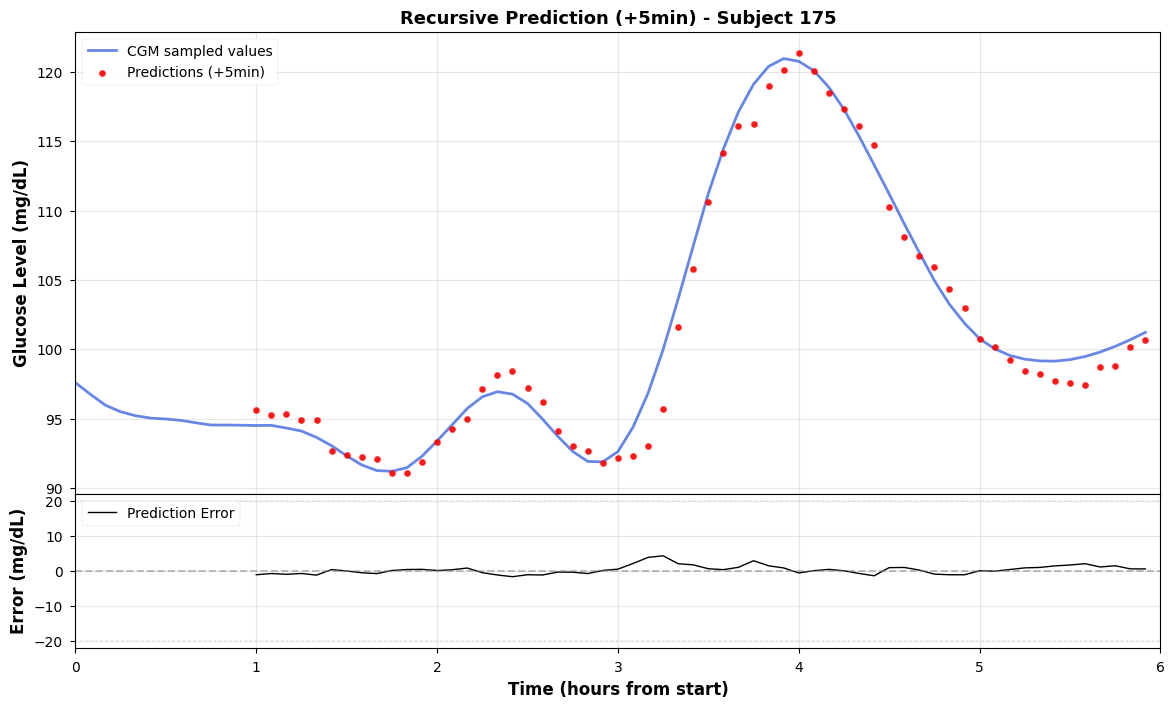

Subject 175 (MAPE 0.94%): Visualization generated.


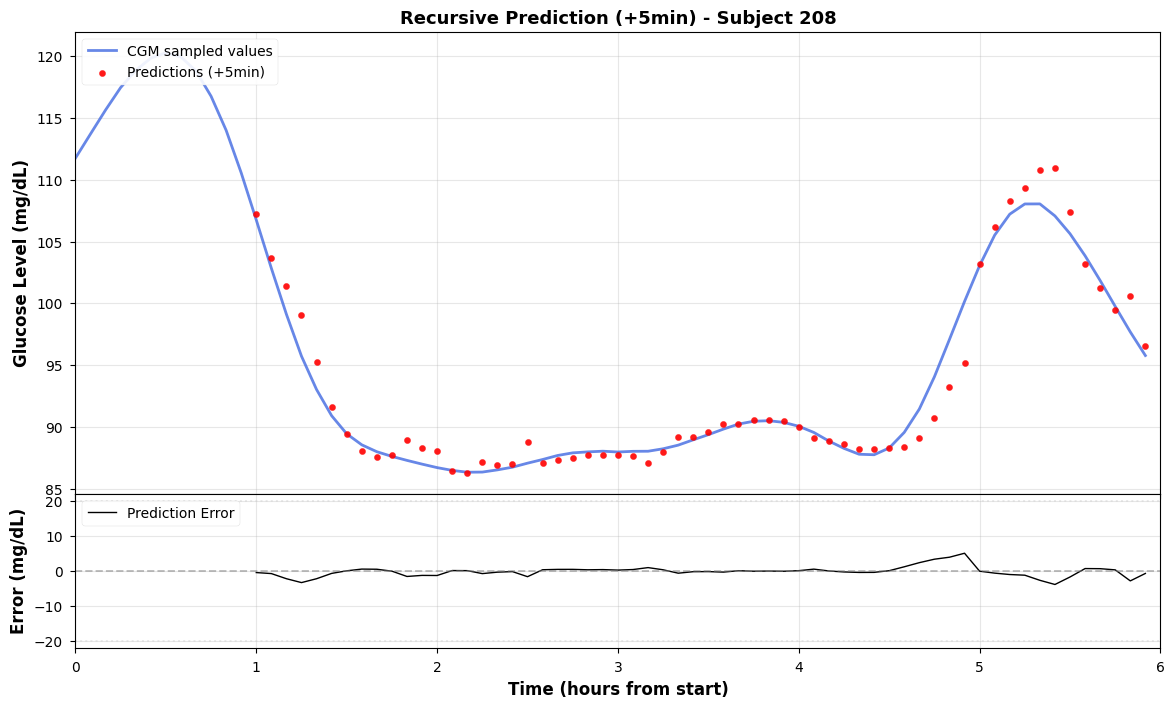

Subject 208 (MAPE 1.01%): Visualization generated.


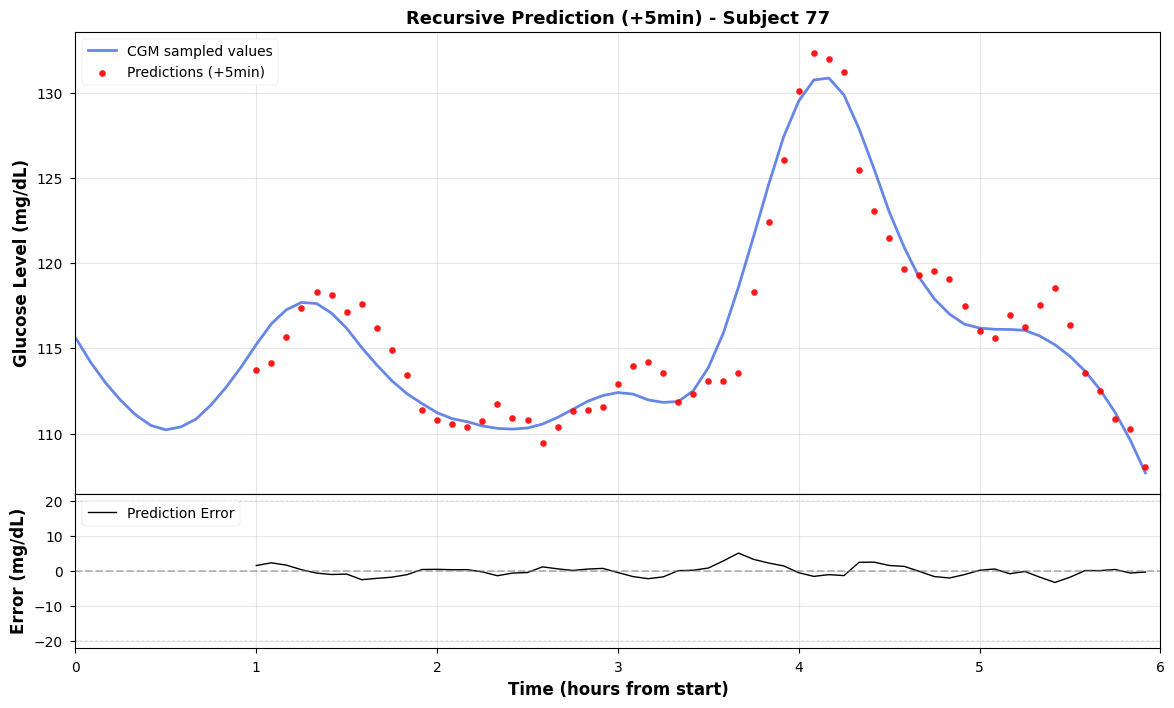

Subject 77 (MAPE 1.03%): Visualization generated.


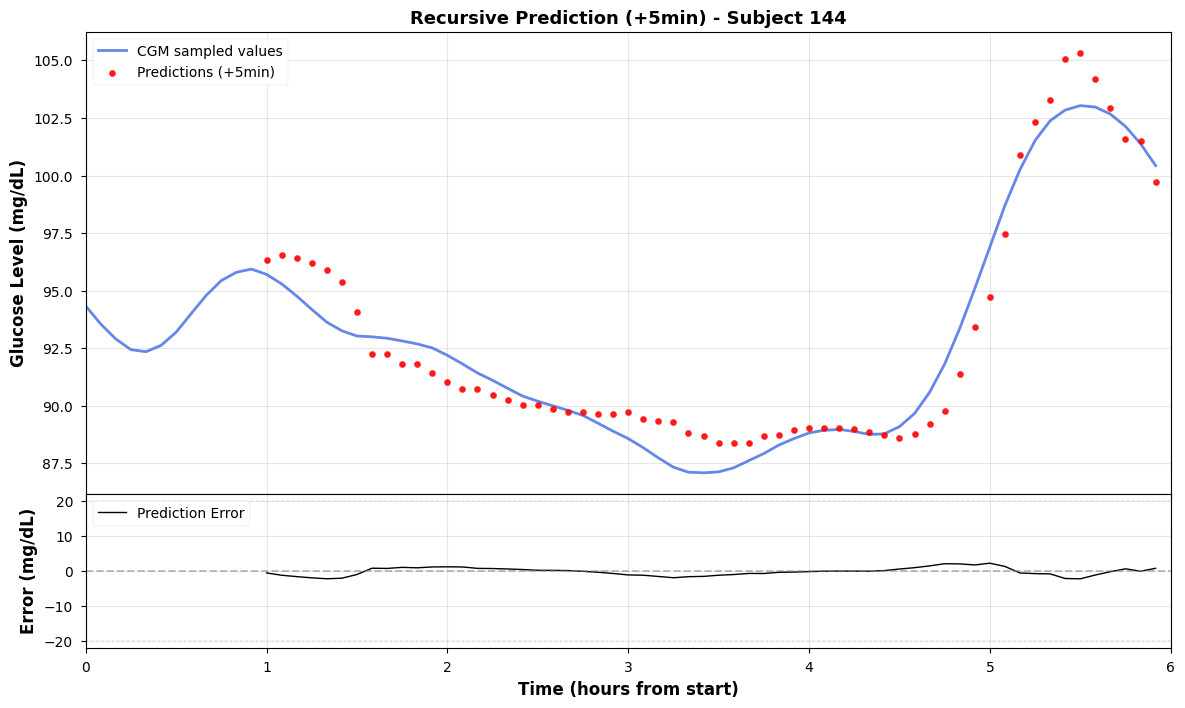

Subject 144 (MAPE 1.03%): Visualization generated.


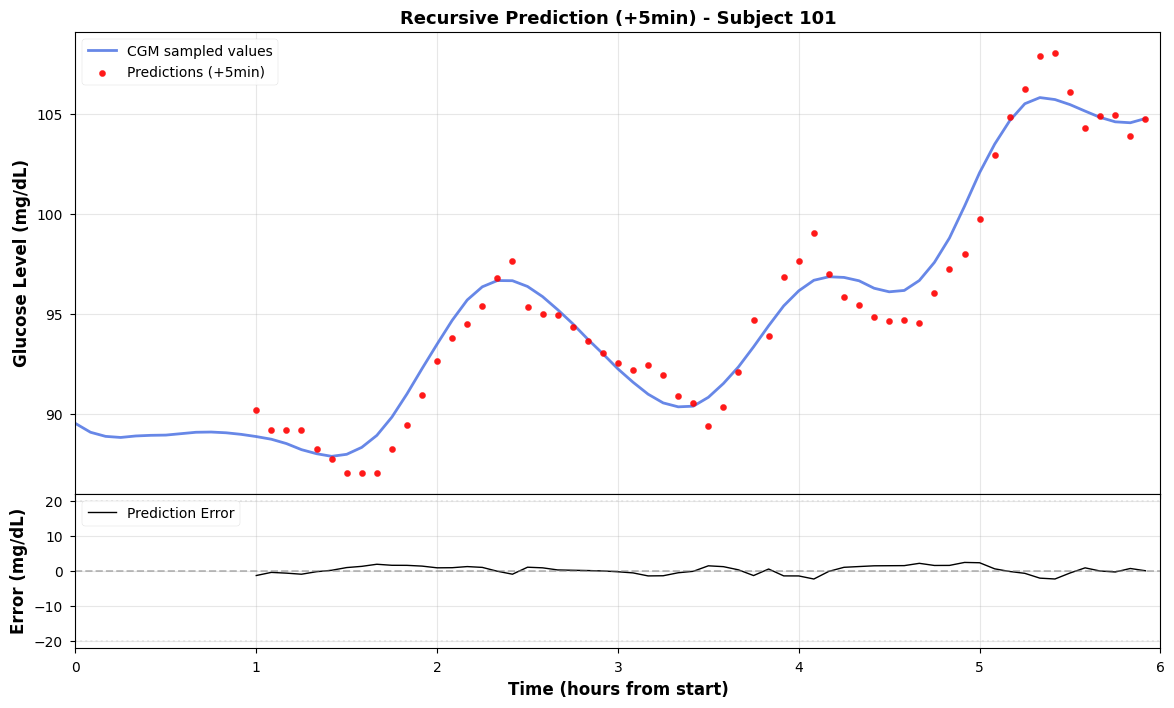

Subject 101 (MAPE 1.04%): Visualization generated.


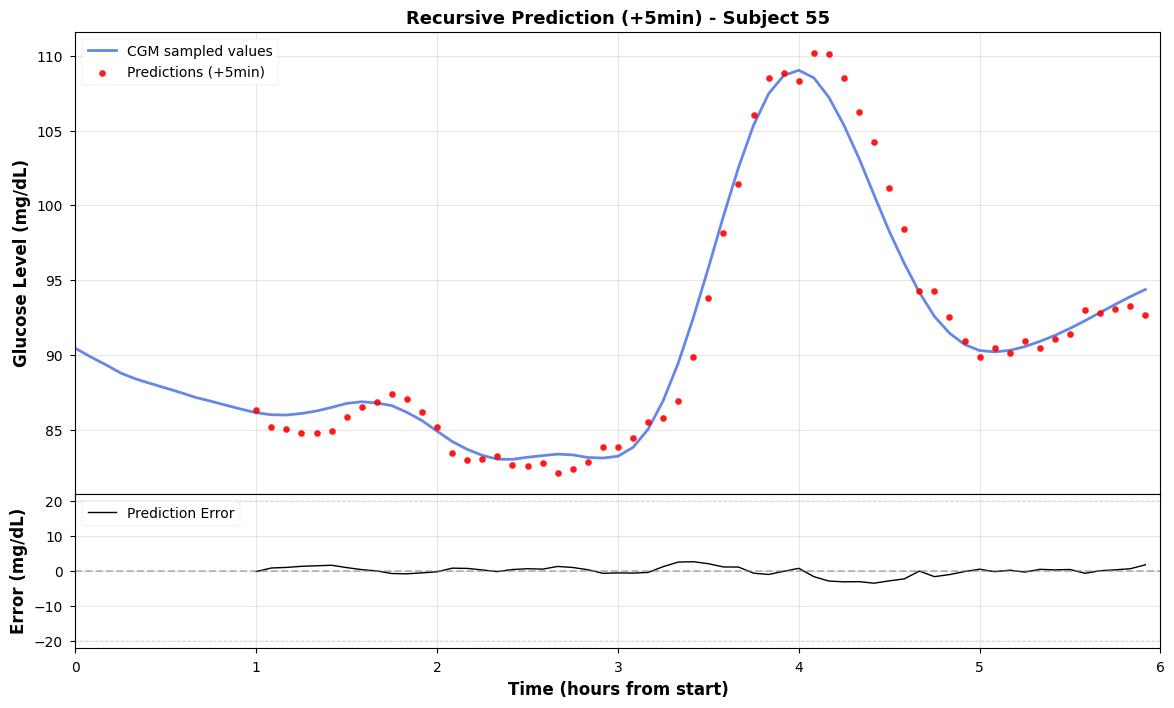

Subject 55 (MAPE 1.06%): Visualization generated.


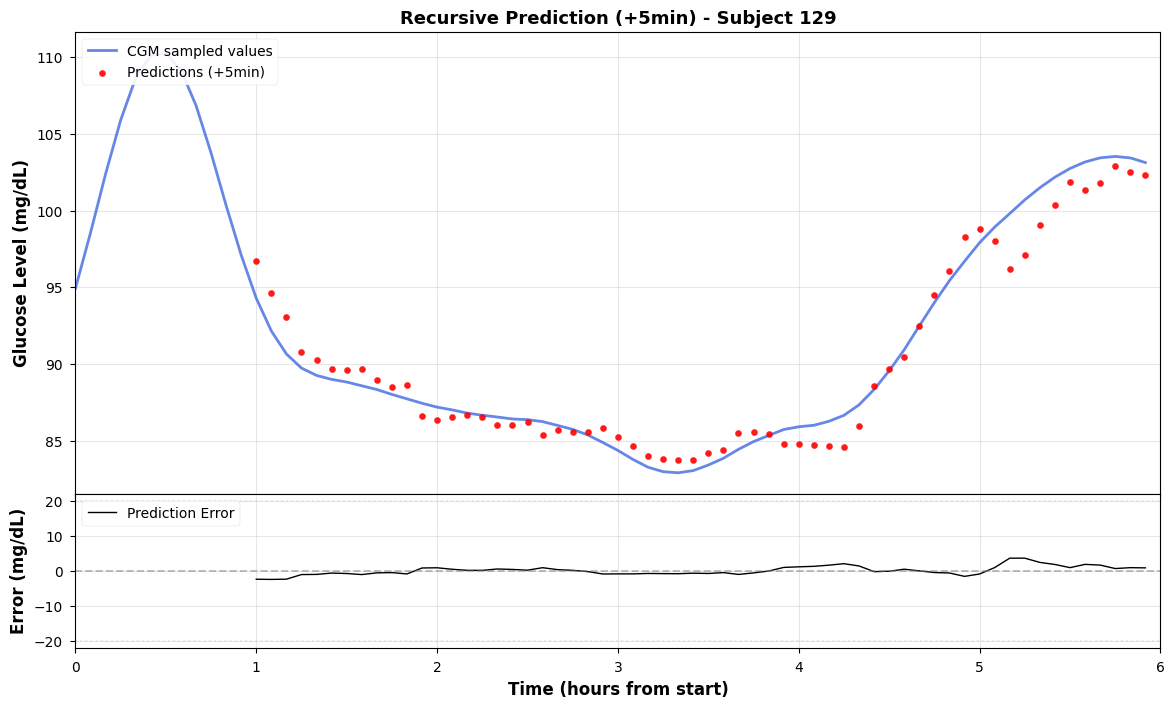

Subject 129 (MAPE 1.08%): Visualization generated.


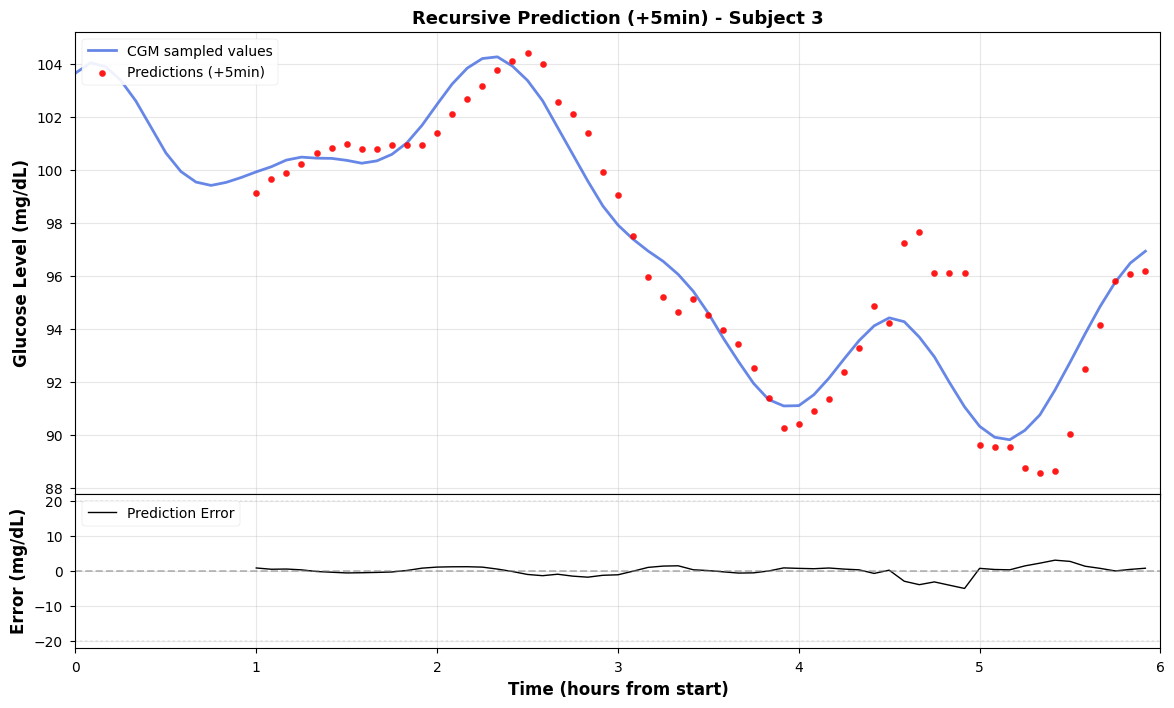

Subject 3 (MAPE 1.11%): Visualization generated.


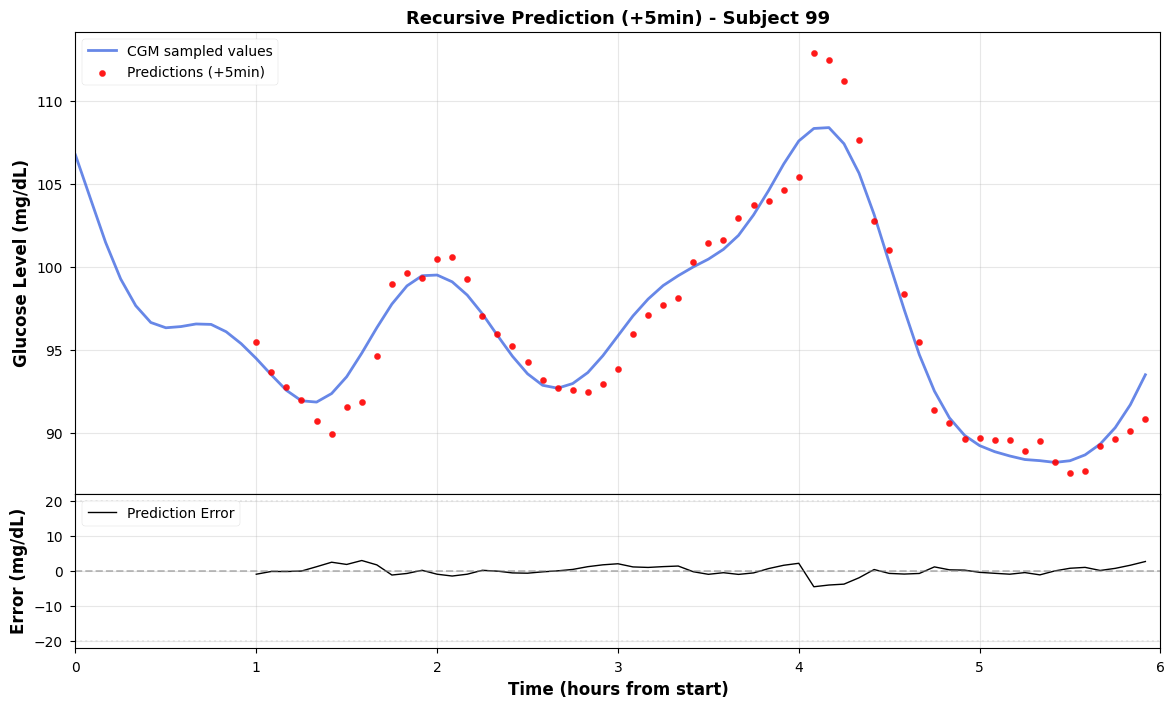

Subject 99 (MAPE 1.12%): Visualization generated.


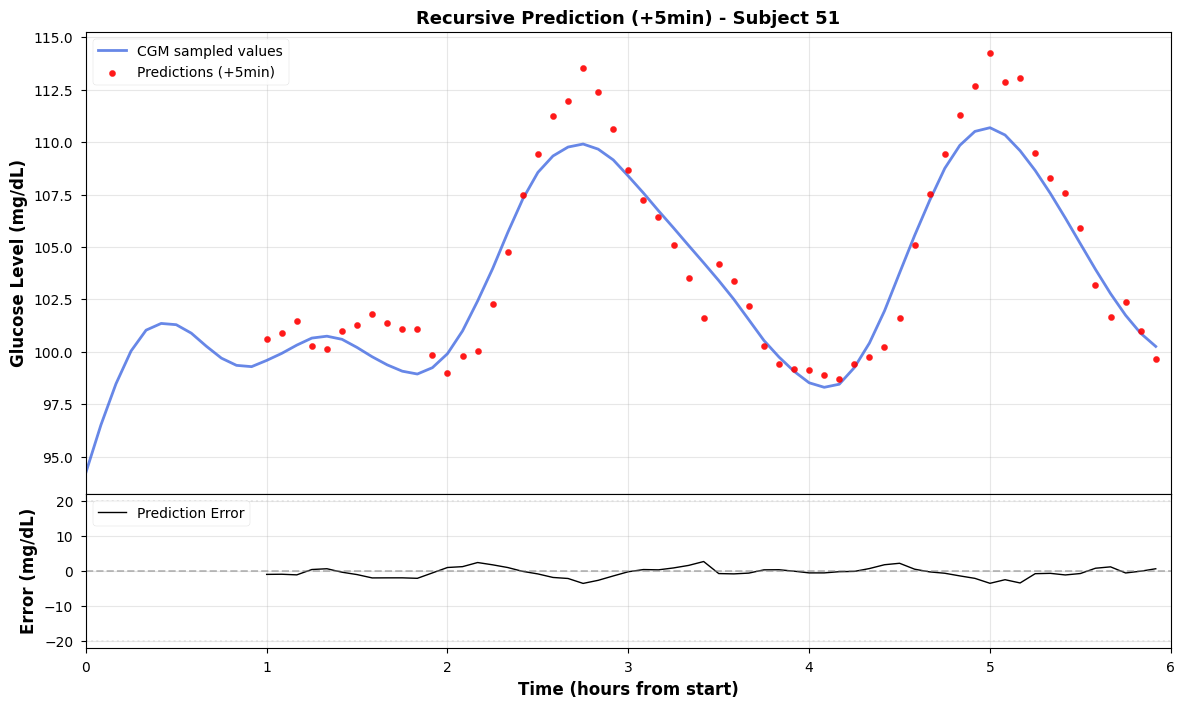

Subject 51 (MAPE 1.13%): Visualization generated.


In [100]:
import matplotlib.dates as mdates

# 获取测试集中所有受试者的 ID（已排序）
subject_ids = sorted(df_test['id'].unique())

# 先计算每个受试者的 MAPE，用于挑选前 10 名
subject_stats = []

# 我们需要重新对齐预测值到受试者
# y_pred_horizon 是所有受试者有效样本的拼接
# 我们需要知道每个受试者有多少个有效样本

current_pred_idx = 0

for subject_id in subject_ids:
    # 提取该受试者数据
    subject_data = df_test[df_test['id'] == subject_id].copy().sort_values('time')
    gl_values = subject_data['gl'].values
    
    # 计算该受试者的有效样本数 (与 get_multistep_targets 逻辑一致)
    # 总窗口数
    n_windows = len(gl_values) - N_PAST
    if n_windows <= 0:
        continue
        
    # 有效的多步预测样本数
    n_valid = len(gl_values) - N_PAST - PREDICTION_HORIZON + 1
    
    if n_valid <= 0:
        continue

    # 提取该受试者的预测值和真实值
    y_pred_subj = y_pred_horizon[current_pred_idx : current_pred_idx + n_valid]
    
    # 真实值: 从 N_PAST + HORIZON - 1 开始
    y_true_subj = gl_values[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + n_valid]
    
    current_pred_idx += n_valid

    # 计算 MAPE
    mask = y_true_subj != 0
    if mask.any():
        mape_subj = np.mean(np.abs((y_true_subj[mask] - y_pred_subj[mask]) / y_true_subj[mask])) * 100
    else:
        mape_subj = np.nan

    subject_stats.append({
        'id': subject_id,
        'mape': mape_subj,
        'data': subject_data,
        'y_true': y_true_subj,
        'y_pred': y_pred_subj,
    })

# 按 MAPE 升序取前 10 个受试者
subject_stats = [s for s in subject_stats if not np.isnan(s['mape'])]
subject_stats = sorted(subject_stats, key=lambda x: x['mape'])[:10]

# 绘图
for stat in subject_stats:
    subject_id = stat['id']
    subject_data = stat['data']
    y_true_subj = stat['y_true']
    y_pred_subj = stat['y_pred']
    error = y_true_subj - y_pred_subj

    # 构造时间轴
    full_hours = np.arange(len(subject_data)) * (5 / 60)
    # 预测值对应的时间点
    pred_hours = full_hours[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + len(y_pred_subj)]

    y_true_full = subject_data['gl'].values

    # 绘图
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
    )
    
    ax1.plot(full_hours, y_true_full, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    ax1.scatter(pred_hours, y_pred_subj, label=f'Predictions (+{PREDICTION_HORIZON*5}min)', color='red', s=20, alpha=0.9, zorder=5)
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'Recursive Prediction (+{PREDICTION_HORIZON*5}min) - Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(pred_hours, error, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    
    ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    ax2.set_xlim(0, 6)

    plt.show()
    print(f"Subject {subject_id} (MAPE {stat['mape']:.2f}%): Visualization generated.")

Served 数据集加载完成，形状: (6967, 5)
正在构建 Served 集多步真实标签...
有效 Served 样本数: 6847
正在对 Served Set 进行递归预测...
------------------------------
Served Set 评估结果 (Horizon=1):
MAE: 2.4008 mg/dL
RMSE: 3.4147 mg/dL
MAPE: 2.6054%
RMSPE: 4.0220%
------------------------------


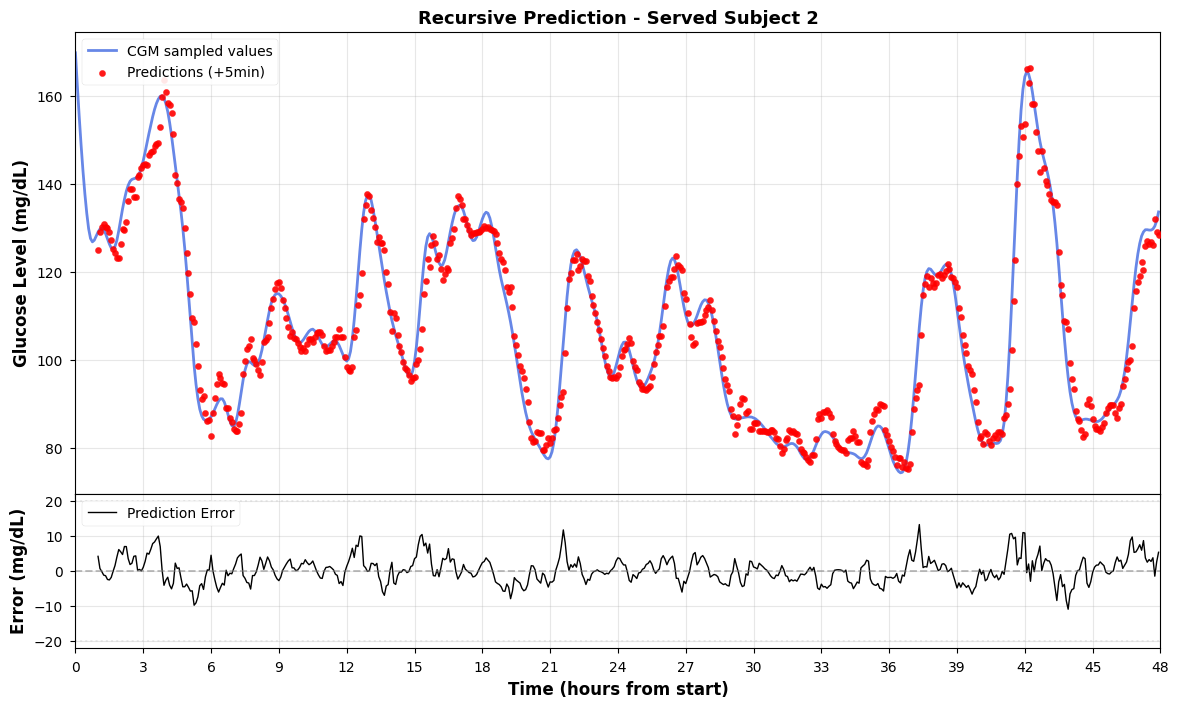

Served Subject 2: Visualization generated.


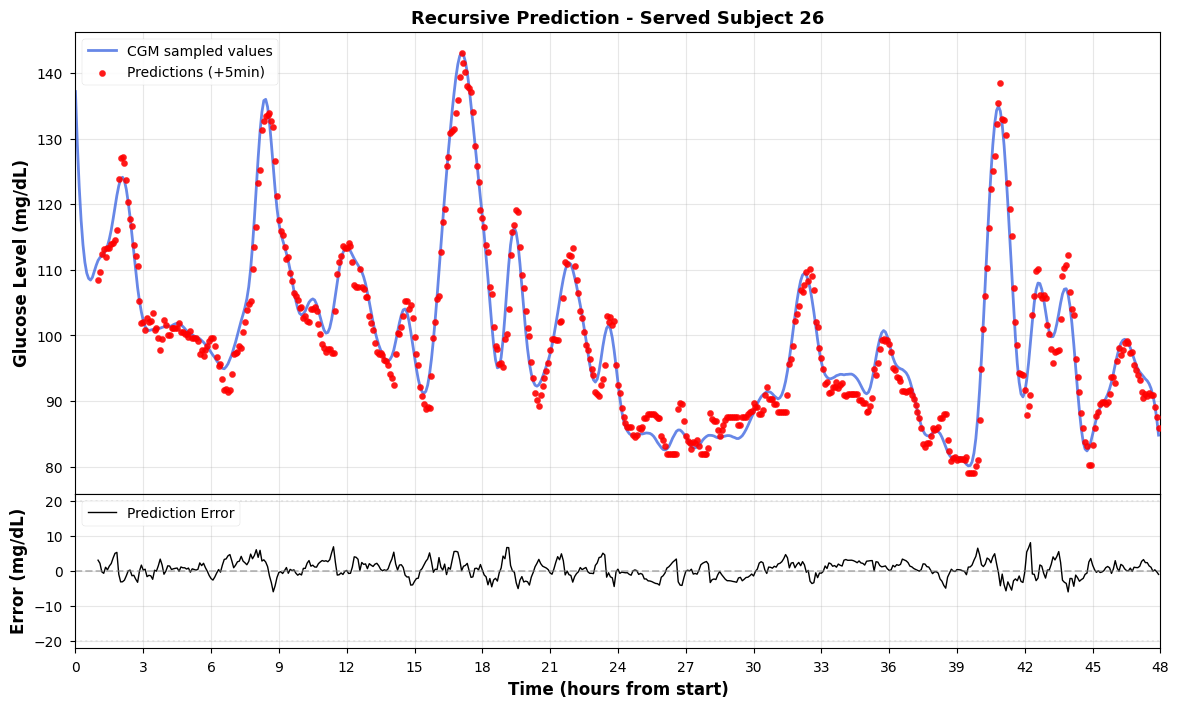

Served Subject 26: Visualization generated.


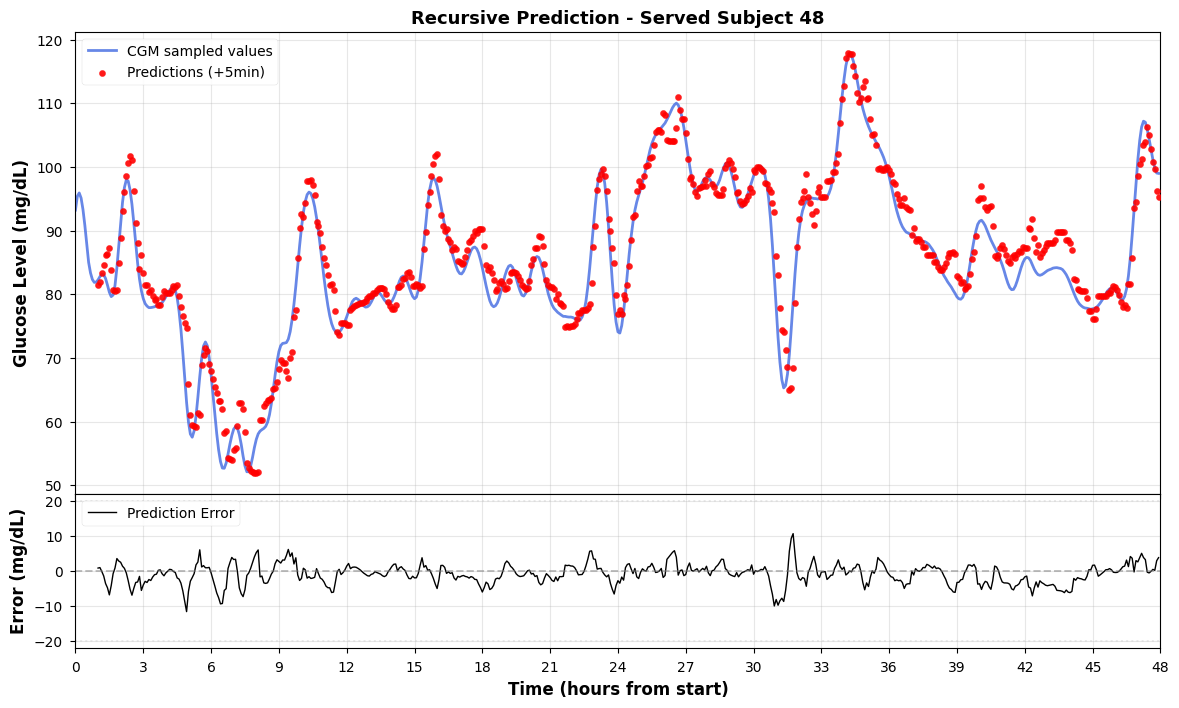

Served Subject 48: Visualization generated.


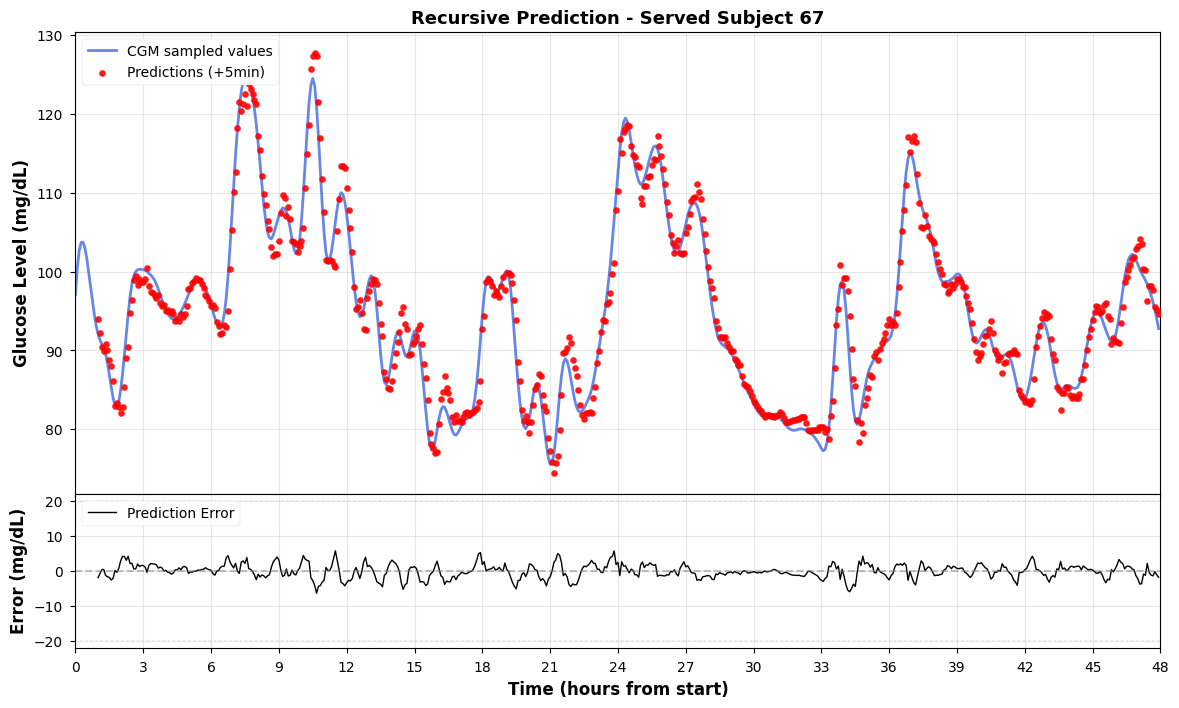

Served Subject 67: Visualization generated.


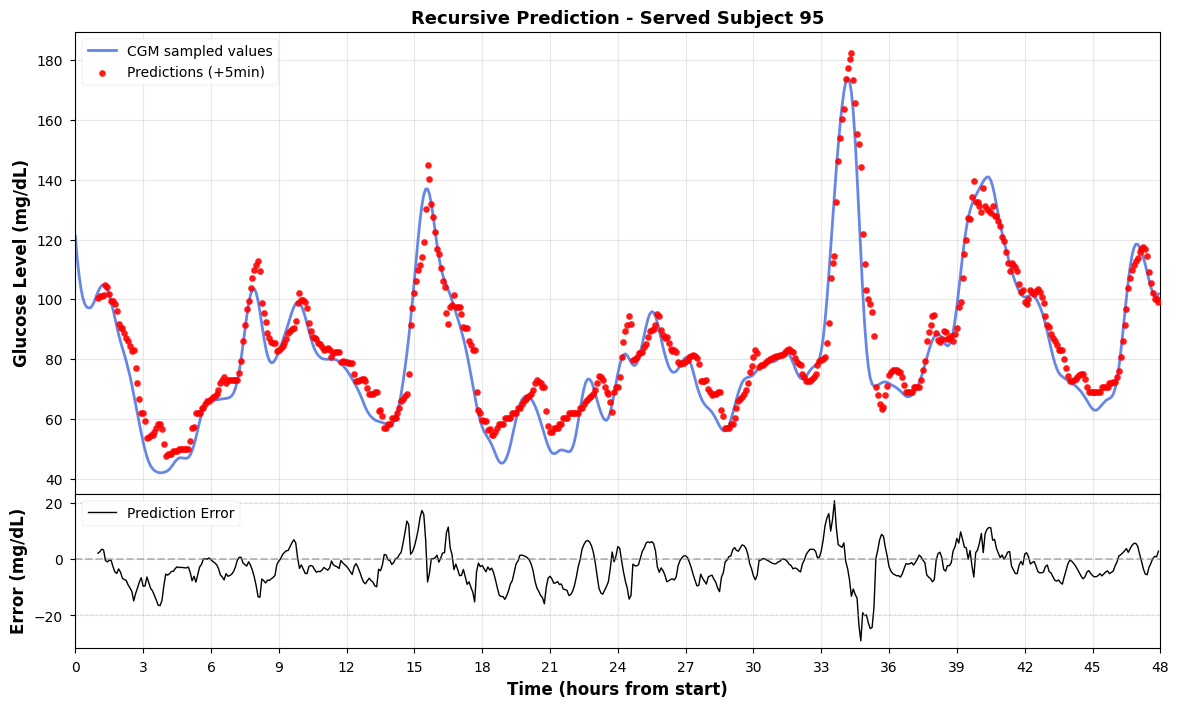

Served Subject 95: Visualization generated.


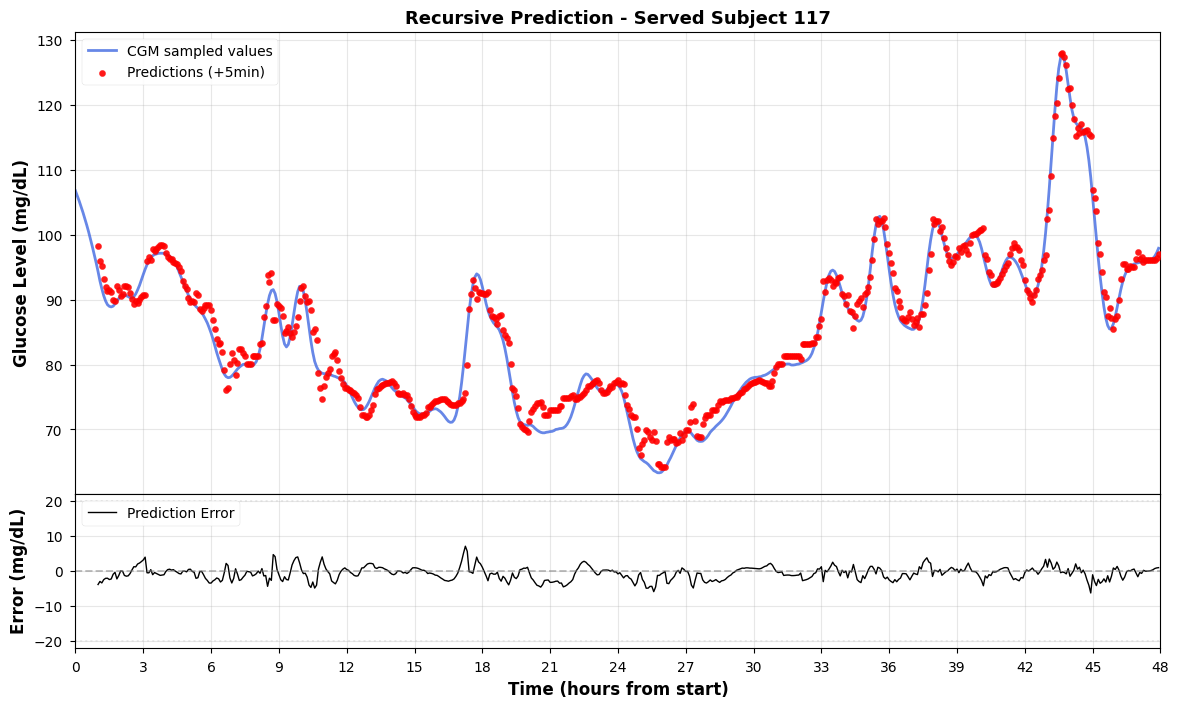

Served Subject 117: Visualization generated.


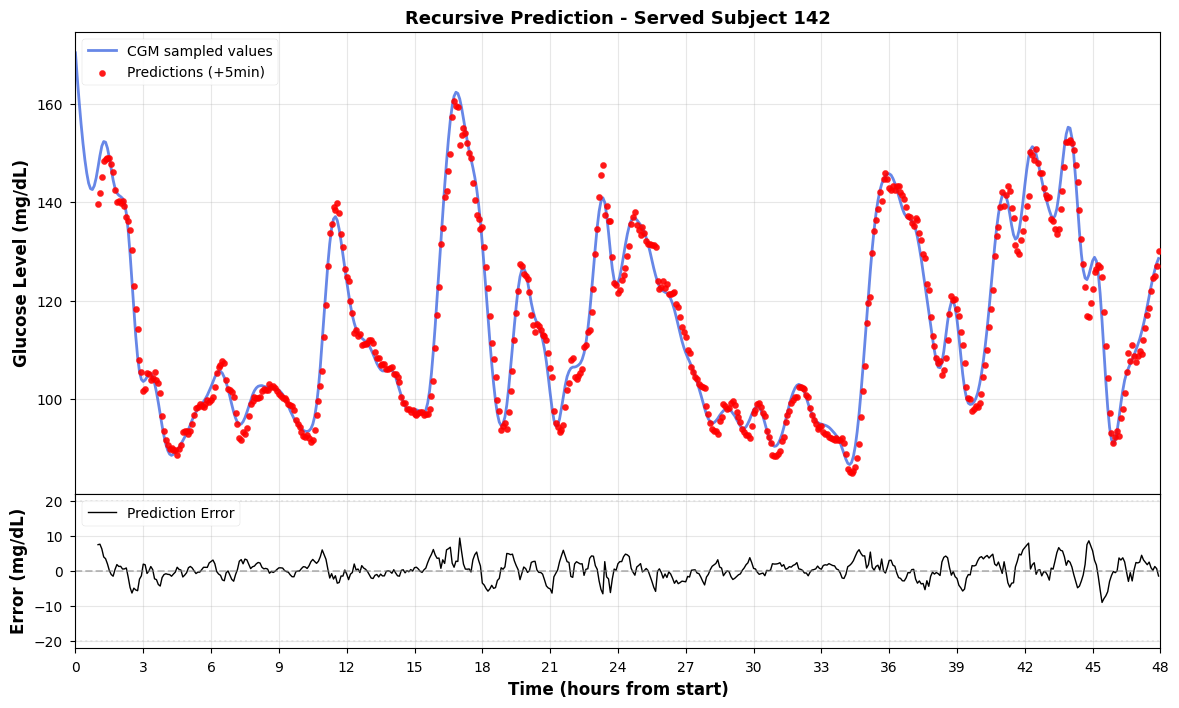

Served Subject 142: Visualization generated.


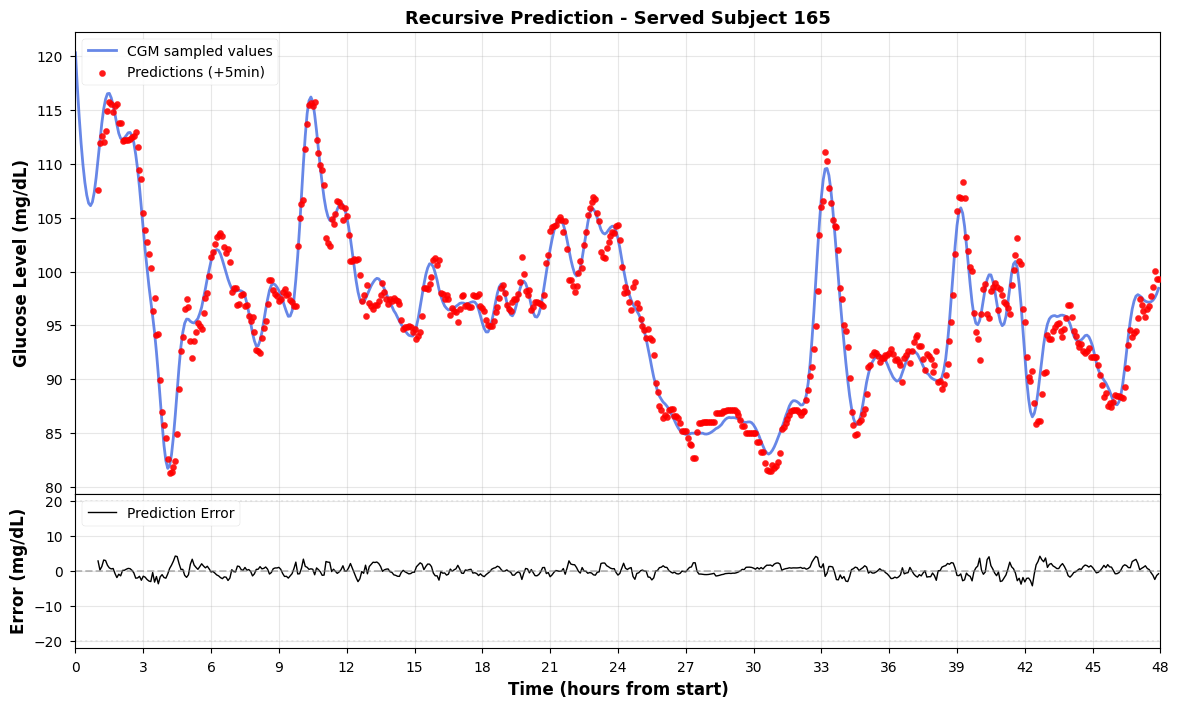

Served Subject 165: Visualization generated.


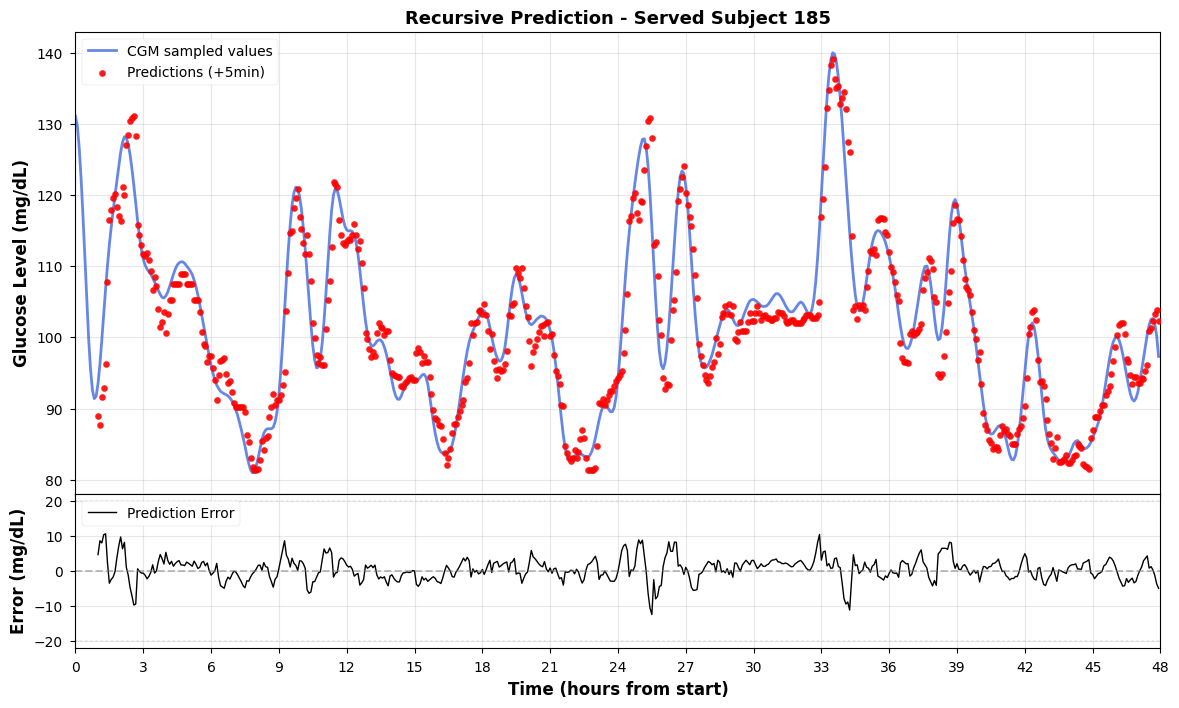

Served Subject 185: Visualization generated.


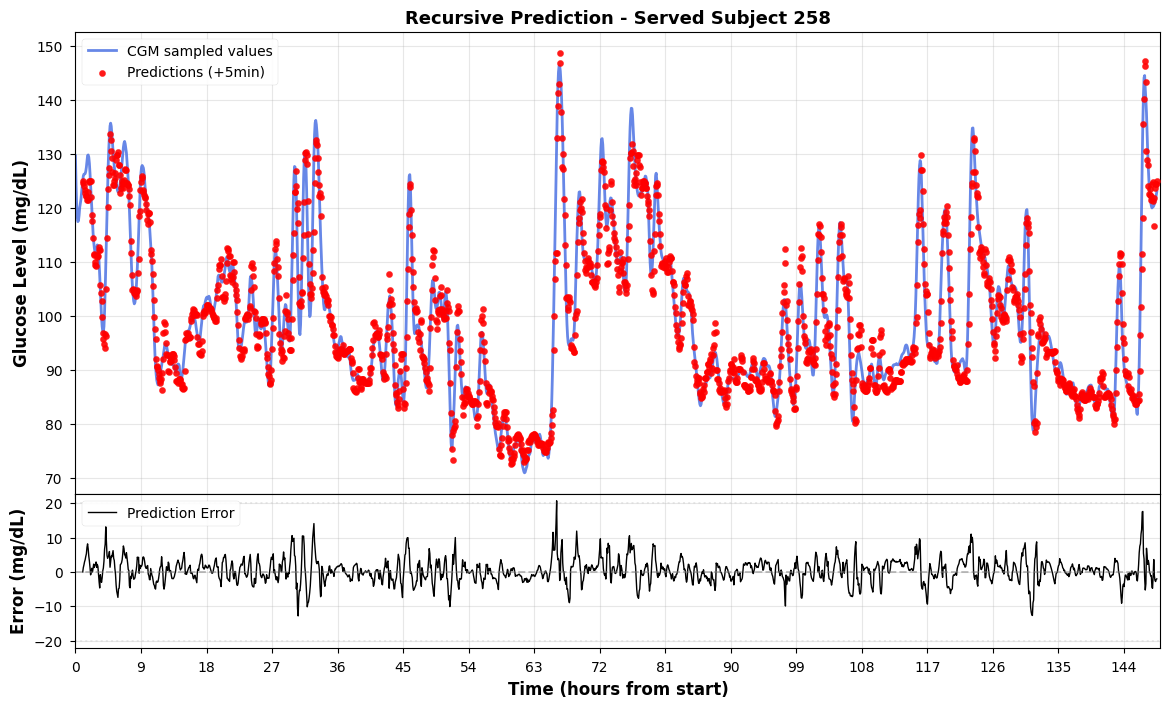

Served Subject 258: Visualization generated.


In [101]:
# --- 新增模块：Served Set (长期预测) 分析 ---

# 1. 加载 Served 数据集
served_path = '../../DataSplit/Served/served.csv'
df_served = pd.read_csv(served_path, parse_dates=['time'])
print(f"Served 数据集加载完成，形状: {df_served.shape}")

# 2. 获取 Served Set 的真实标签
print("正在构建 Served 集多步真实标签...")
y_served_horizon, valid_indices_s = get_multistep_targets(df_served, N_PAST, PREDICTION_HORIZON)

print(f"有效 Served 样本数: {len(valid_indices_s)}")

# 3. 对 Served Set 每个样本进行递归预测
print(f"正在对 Served Set 进行递归预测...")

y_pred_served_list = []

for subject_id, group in df_served.groupby('id'):
    gl_values = group['gl'].values
    age = group['age'].iloc[0]
    bmi = group['bmi'].iloc[0]
    
    if len(gl_values) <= N_PAST + PREDICTION_HORIZON:
        continue
    
    for i in range(N_PAST, len(gl_values) - PREDICTION_HORIZON + 1):
        window_glucose = gl_values[i - N_PAST : i]
        
        predictions = recursive_predict_single(
            knn_model,
            scaler,
            window_glucose,
            age,
            bmi,
            PREDICTION_HORIZON
        )
        
        y_pred_served_list.append(predictions[-1])

y_pred_served = np.array(y_pred_served_list)

# 4. 计算评估指标
mae_s, rmse_s, mape_s, rmspe_s = calculate_metrics(y_served_horizon, y_pred_served)
print("-" * 30)
print(f"Served Set 评估结果 (Horizon={PREDICTION_HORIZON}):")
print(f"MAE: {mae_s:.4f} mg/dL")
print(f"RMSE: {rmse_s:.4f} mg/dL")
print(f"MAPE: {mape_s:.4f}%")
print(f"RMSPE: {rmspe_s:.4f}%")
print("-" * 30)

# 5. 可视化
subject_ids_served = sorted(df_served['id'].unique())
current_idx_s = 0

for subject_id in subject_ids_served:
    subject_data = df_served[df_served['id'] == subject_id].copy().sort_values('time')
    gl_values = subject_data['gl'].values
    
    n_valid = len(gl_values) - N_PAST - PREDICTION_HORIZON + 1
    if n_valid <= 0:
        continue
        
    y_pred_s = y_pred_served[current_idx_s : current_idx_s + n_valid]
    y_true_s = gl_values[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + n_valid]
    current_idx_s += n_valid
    
    error_s = y_true_s - y_pred_s
    
    full_hours = np.arange(len(subject_data)) * (5 / 60)
    pred_hours = full_hours[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + n_valid]
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
    )
    
    ax1.plot(full_hours, gl_values, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    ax1.scatter(pred_hours, y_pred_s, label=f'Predictions (+{PREDICTION_HORIZON*5}min)', color='red', s=20, alpha=0.9, zorder=5)
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'Recursive Prediction - Served Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(pred_hours, error_s, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    
    max_hours = np.ceil(full_hours[-1])
    ax2.set_xlim(0, max_hours)
    tick_interval = max(1, int(max_hours / 15)) 
    ax2.xaxis.set_major_locator(plt.MultipleLocator(tick_interval))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    
    plt.show()
    print(f"Served Subject {subject_id}: Visualization generated.")

正在绘制标准 Clarke Error Grid...


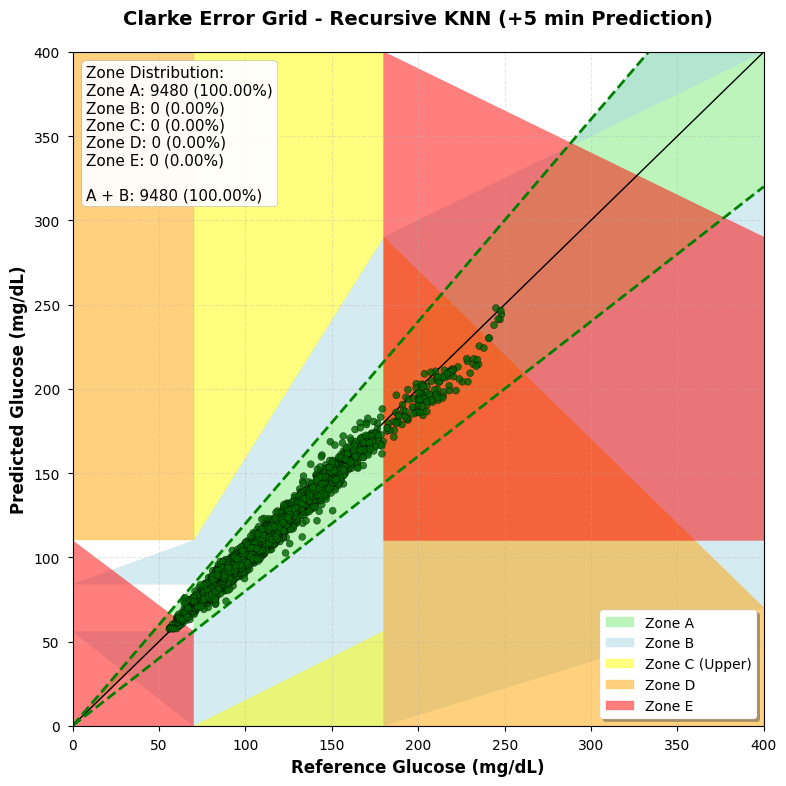


各区临床统计:
  Zone A: 100.00%
  Zone B: 0.00%
  Zone C: 0.00%
  Zone D: 0.00%
  Zone E: 0.00%
  A + B (临床安全): 100.00%


In [ ]:
def clarke_error_grid(ref_values, pred_values, title="Clarke Error Grid"):
    """
    """
    ref = np.array(ref_values)
    pred = np.array(pred_values)
    
    # 创建画布
    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    
    # 主对角线
    plt.plot([0, 400], [0, 400], color='black', linewidth=1, linestyle='-')
    
    # ================== Zone A (临床准确) ==================
    # 上边界：y = 1.2x (x <= 70时特殊处理)
    plt.plot([0, 70, 400], [0, 84, 480], 'green', linewidth=2, linestyle='--')
    # 下边界：y = 0.8x
    plt.plot([0, 70, 400], [0, 56, 320], 'green', linewidth=2, linestyle='--')
    # 低血糖区特殊处理
    plt.fill([0, 70, 70, 0], [0, 70, 84, 0], color='lightgreen', alpha=0.6, label='Zone A')
    plt.fill([70, 400, 400, 70], [84, 480, 320, 56], color='lightgreen', alpha=0.6)
    
    # ================== Zone B (良性误差) ==================
    # 上B区
    plt.fill([0, 70, 180, 400, 400, 70, 0], 
             [84, 110, 290, 400, 480, 84, 84], 
             color='lightblue', alpha=0.5, label='Zone B')
    # 下B区
    plt.fill([0, 70, 180, 400, 400, 70, 0], 
             [56, 0, 0, 70, 320, 56, 56], 
             color='lightblue', alpha=0.5)
    
    # ================== Zone C (过度纠正) ==================
    plt.fill([70, 180, 180, 70], [110, 290, 400, 400], color='yellow', alpha=0.5, label='Zone C (Upper)')
    plt.fill([70, 180, 180, 70], [0, 0, 56, 0], color='yellow', alpha=0.5)
    
    # ================== Zone D (危险失败) ==================
    # 高血糖未检测
    plt.fill([180, 400, 400, 180], [0, 0, 70, 290], color='orange', alpha=0.5, label='Zone D')
    # 低血糖过度纠正
    plt.fill([0, 70, 70, 0], [110, 110, 400, 400], color='orange', alpha=0.5)
    
    # ================== Zone E (错误治疗) ==================
    plt.fill([180, 400, 400, 180], [110, 110, 290, 400], color='red', alpha=0.5, label='Zone E')
    plt.fill([0, 70, 70, 0], [0, 0, 56, 110], color='red', alpha=0.5)
    
    # ================== 散点着色 ==================
    zones = {'A': 0, 'B': 0, 'C': 0, 'D': 0, 'E': 0}
    colors = []
    
    for r, p in zip(ref, pred):
        if (abs(r - p) <= max(15, 0.2 * r)):  # 简化A区判断（标准近似）
            zones['A'] += 1
            colors.append('darkgreen')
        elif (r >= 180 and p <= 70) or (r <= 70 and p >= 180):
            zones['E'] += 1
            colors.append('darkred')
        elif (r >= 180 and 70 < p <= 180) or (r <= 70 and 70 < p <= 180):
            zones['D'] += 1
            colors.append('darkorange')
        elif (r >= 70 and (p > r + 110 or p < r - 110)) or \
             (r < 70 and (p > 180 or p < 55)):
            zones['C'] += 1
            colors.append('purple')
        else:
            zones['B'] += 1
            colors.append('steelblue')
    
    plt.scatter(ref, pred, c=colors, s=25, alpha=0.8, edgecolors='k', linewidth=0.3, zorder=10)
    
    # ================== 坐标轴设置 ==================
    plt.xlim(0, 400)
    plt.ylim(0, 400)
    plt.xlabel('Reference Glucose (mg/dL)', fontsize=12, fontweight='bold')
    plt.ylabel('Predicted Glucose (mg/dL)', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # ================== 统计信息 ==================
    total = len(ref)
    stats_text = "Zone Distribution:\n"
    for zone in ['A', 'B', 'C', 'D', 'E']:
        pct = zones[zone] / total * 100
        stats_text += f"Zone {zone}: {zones[zone]} ({pct:.2f}%)\n"
    stats_text += f"\nA + B: {zones['A'] + zones['B']} ({(zones['A'] + zones['B'])/total*100:.2f}%)"
    
    plt.text(0.02, 0.98, stats_text, transform=ax.transAxes,
             verticalalignment='top', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray'))
    
    plt.legend(loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    plt.tight_layout()
    plt.show()
    
    # 返回百分比
    return {k: v / total * 100 for k, v in zones.items()}


# ============ 直接调用（粘贴后运行这部分） ============
print("=" * 60)
print("正在绘制标准 Clarke Error Grid...")
print("=" * 60)

zones_pct = clarke_error_grid(
    y_test_horizon, 
    y_pred_horizon, 
    title=f"Clarke Error Grid - Recursive KNN (+{PREDICTION_HORIZON*5} min Prediction)"
)

print("\n各区临床统计:")
for zone in ['A', 'B', 'C', 'D', 'E']:
    print(f"  Zone {zone}: {zones_pct[zone]:.2f}%")
print(f"  A + B (临床安全): {zones_pct['A'] + zones_pct['B']:.2f}%")